In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [3]:
# Load the MNIST dataset
(x_train, _), (_, _) = mnist.load_data()
x_train = (x_train.astype('float32') - 127.5) / 127.5  # Normalize to [-1, 1]
x_train = np.expand_dims(x_train, axis=-1)  # Reshape for the network (batch, 28, 28, 1)

In [4]:
# Noise Scheduler
T = 1000

betas = np.linspace(1e-4, 0.02, T)
alphas = 1.0 - betas
alpha_bar = np.cumprod(alphas)

In [11]:
# Forward diffusion
def forward_diffusion(x0, t):
    noise = np.random.normal(size=x0.shape)

    a_bar = alpha_bar[t.flatten()]             # (B,)
    a_bar = a_bar.reshape(-1, 1, 1, 1)         # (B,1,1,1)

    xt = np.sqrt(a_bar) * x0 + np.sqrt(1 - a_bar) * noise
    return xt, noise

In [6]:
# Denoiser (Generator)
def build_denoiser():
    inp = layers.Input(shape=(28, 28, 1))
    t = layers.Input(shape=(1,))

    # embed time (VERY simple)
    t_embed = layers.Dense(28 * 28)(t)
    t_embed = layers.Reshape((28, 28, 1))(t_embed)

    x = layers.Concatenate()([inp, t_embed])

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    out = layers.Conv2D(1, 3, padding="same")(x)

    return Model([inp, t], out)

denoiser = build_denoiser()

In [7]:
# Discriminator (on images)
def build_discriminator():
    inp = layers.Input(shape=(28, 28, 1))

    x = layers.Conv2D(64, 4, strides=2, padding="same")(inp)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(128, 4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Flatten()(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    return Model(inp, out)

discriminator = build_discriminator()
discriminator.compile(loss="binary_crossentropy", optimizer=Adam(0.0002, 0.5))

In [8]:
# Combined model (Diffusion + GAN loss)
discriminator.trainable = False

x_in = layers.Input(shape=(28, 28, 1))
t_in = layers.Input(shape=(1,))

denoised = denoiser([x_in, t_in])
validity = discriminator(denoised)

diffusion_gan = Model([x_in, t_in], [denoised, validity])

In [9]:
# Losses
def diffusion_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

def adv_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred)

diffusion_gan.compile(
    optimizer=Adam(0.0002, 0.5),
    loss=[diffusion_loss, adv_loss],
    loss_weights=[1.0, 1e-3]  # GAN is weak (important!)
)

In [12]:
# Training loop
batch_size = 128
epochs = 50

for epoch in range(epochs):
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    imgs = x_train[idx]

    t = np.random.randint(0, T, size=(batch_size, 1))

    xt, noise = forward_diffusion(imgs, t)

    # ======================
    # Train discriminator
    # ======================
    denoised_imgs = denoiser.predict([xt, t], verbose=0)

    d_loss_real = discriminator.train_on_batch(imgs, np.ones((batch_size, 1)))
    d_loss_fake = discriminator.train_on_batch(denoised_imgs, np.zeros((batch_size, 1)))

    # ======================
    # Train diffusion model
    # ======================
    diffusion_gan.train_on_batch(
        [xt, t],
        [noise, np.ones((batch_size, 1))]
    )

    print(f"Epoch {epoch+1} | D_real: {d_loss_real:.3f} | D_fake: {d_loss_fake:.3f}")

/Users/tomcuel/.venvs/global_env/lib/python3.11/site-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 1 | D_real: 0.704 | D_fake: 0.663
Epoch 2 | D_real: 0.677 | D_fake: 0.660
Epoch 3 | D_real: 0.668 | D_fake: 0.660
Epoch 4 | D_real: 0.667 | D_fake: 0.663
Epoch 5 | D_real: 0.667 | D_fake: 0.666
Epoch 6 | D_real: 0.669 | D_fake: 0.669
Epoch 7 | D_real: 0.671 | D_fake: 0.671
Epoch 8 | D_real: 0.673 | D_fake: 0.673
Epoch 9 | D_real: 0.675 | D_fake: 0.675
Epoch 10 | D_real: 0.677 | D_fake: 0.677
Epoch 11 | D_real: 0.678 | D_fake: 0.679
Epoch 12 | D_real: 0.680 | D_fake: 0.680
Epoch 13 | D_real: 0.681 | D_fake: 0.681
Epoch 14 | D_real: 0.682 | D_fake: 0.683
Epoch 15 | D_real: 0.683 | D_fake: 0.684
Epoch 16 | D_real: 0.684 | D_fake: 0.685
Epoch 17 | D_real: 0.685 | D_fake: 0.686
Epoch 18 | D_real: 0.686 | D_fake: 0.686
Epoch 19 | D_real: 0.687 | D_fake: 0.687
Epoch 20 | D_real: 0.687 | D_fake: 0.687
Epoch 21 | D_real: 0.688 | D_fake: 0.688
Epoch 22 | D_real: 0.688 | D_fake: 0.688
Epoch 23 | D_real: 0.689 | D_fake: 0.689
Epoch 24 | D_real: 0.689 | D_fake: 0.689
Epoch 25 | D_real: 0.690 

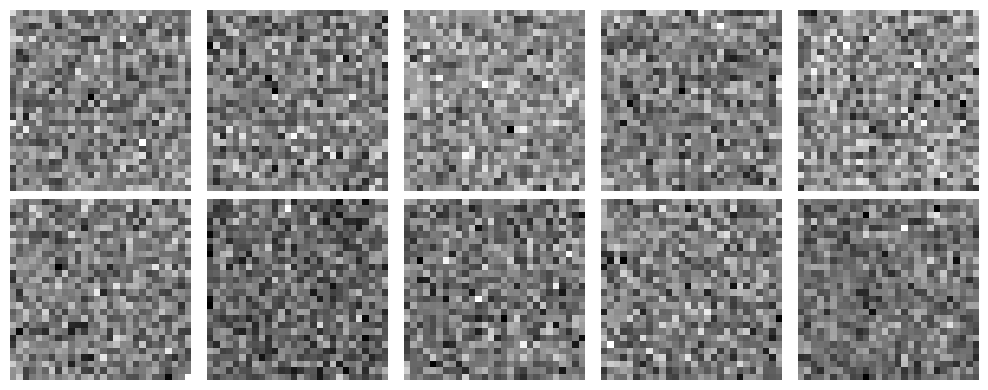

In [15]:
# Sampling (Reverse diffusion)
def sample(n=10):
    x = np.random.normal(size=(n, 28, 28, 1))

    for t in reversed(range(0, T, 50)):  # fast sampling
        t_batch = np.full((n, 1), t)
        noise_pred = denoiser.predict([x, t_batch], verbose=0)

        a = alphas[t]
        a_bar = alpha_bar[t]

        x = (1 / np.sqrt(a)) * (x - (1 - a) / np.sqrt(1 - a_bar) * noise_pred)

    return x

def display_samples(samples, n=10):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(samples[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

display_samples(sample(10), n=10)